<a href="https://colab.research.google.com/github/aditi-tawade-ai/Wine_Type_Prediction/blob/main/Wine_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# loading data
path = '/content/archive.zip'
wn = pd.read_csv(path)
wn[:2]

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050


In [ ]:
wn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
wn.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

In [ ]:
wn.Wine.unique()

array([1, 2, 3])

# Preprocessing

In [ ]:
wn.isna().sum()

,0
Wine,0
Alcohol,0
Malic.acid,0
Ash,0
Acl,0
Mg,0
Phenols,0
Flavanoids,0
Nonflavanoid.phenols,0
Proanth,0


No missing values

In [ ]:
wn.describe().T

,count,mean,std,min,25%,50%,75%,max
Wine,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic.acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Acl,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Mg,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid.phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanth,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


No outliers

# Analysis

In [ ]:
a = ['Wine','Alcohol','Malic.acid','Ash','Phenols','Flavanoids']

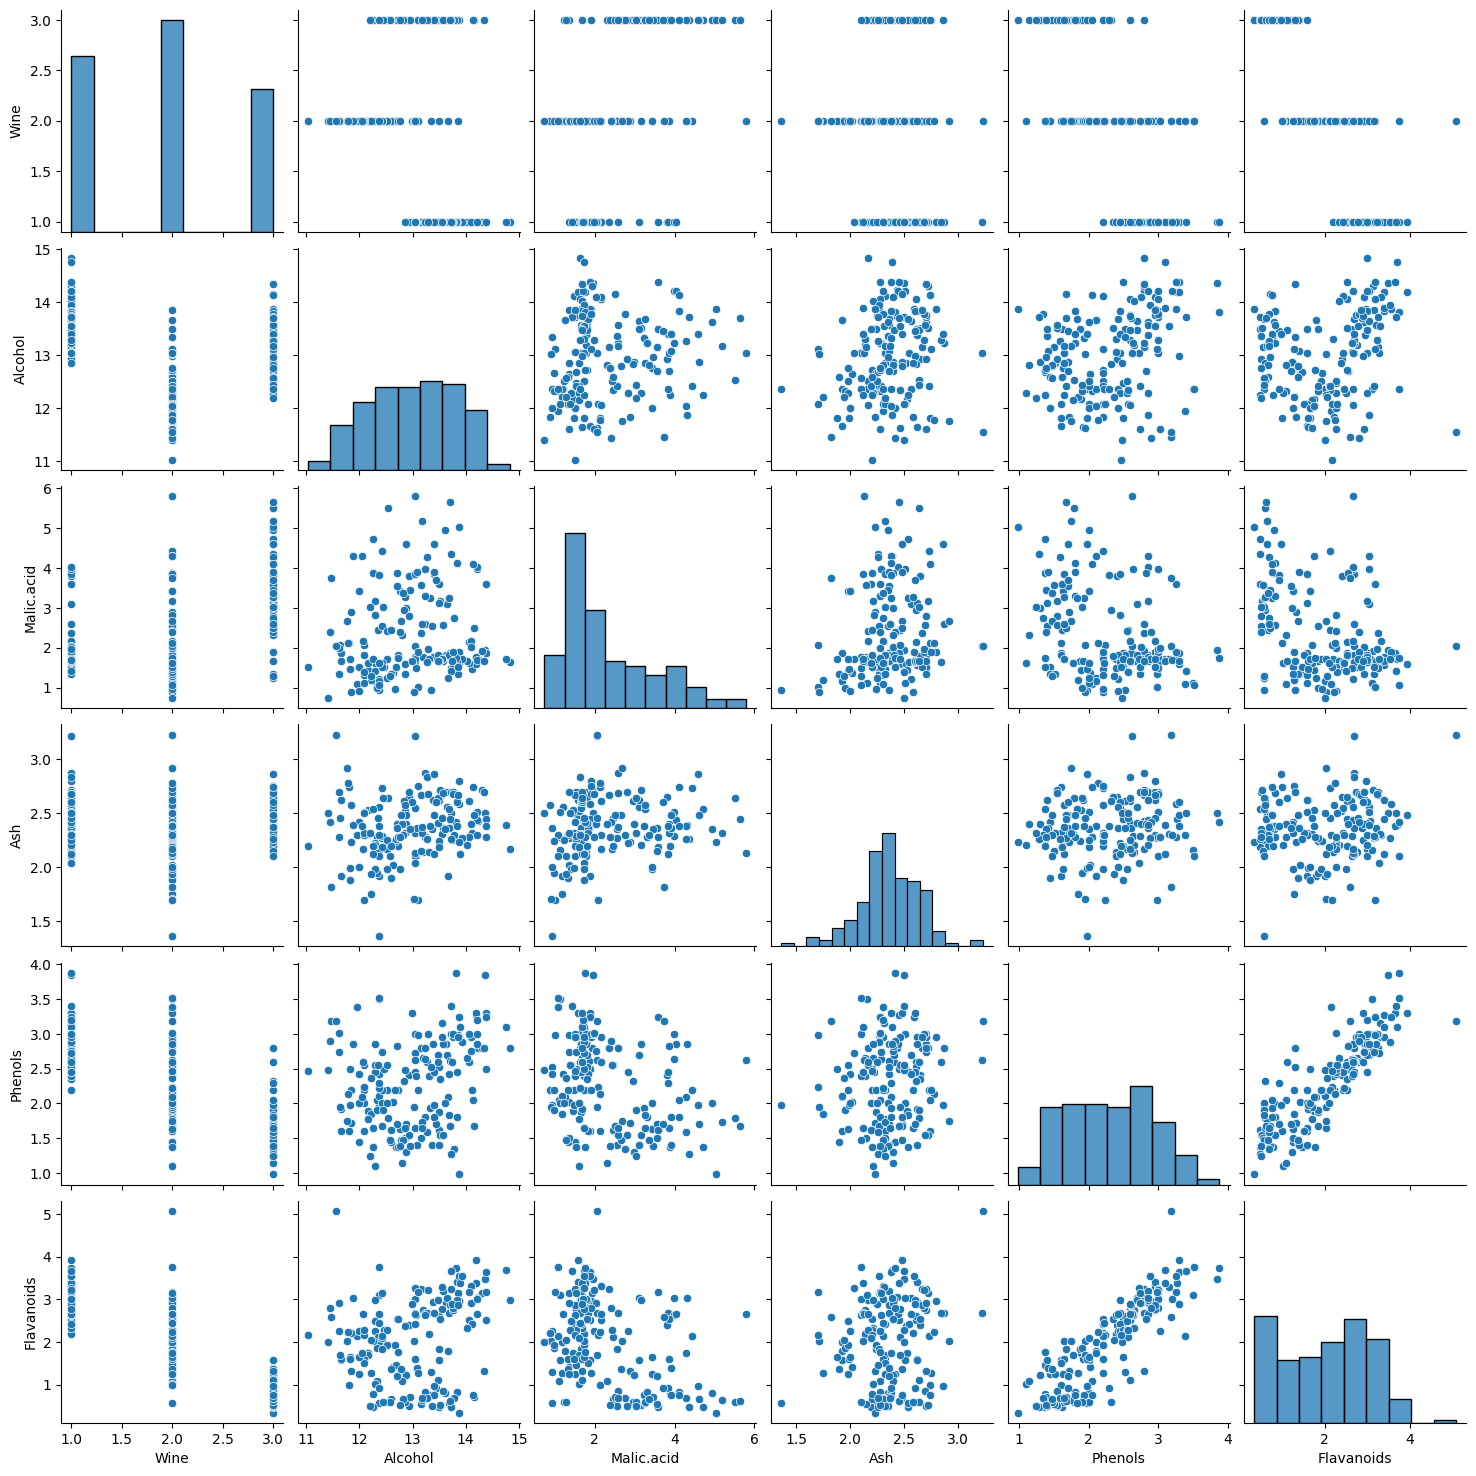

In [ ]:
sns.pairplot(data=wn[a])

From above plot we understand the problem is of Logestic regression

# Spliting the data

In [ ]:
wn.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

In [ ]:
X = wn[['Alcohol','Malic.acid','Ash','Phenols','Flavanoids']]
y = wn['Wine']

In [ ]:
X[:2]

,Alcohol,Malic.acid,Ash,Phenols,Flavanoids
0,14.23,1.71,2.43,2.80,3.06
1,13.20,1.78,2.14,2.65,2.76


In [ ]:
y[:2]

,Wine
0,1
1,1


# Train test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train[:2]

,Alcohol,Malic.acid,Ash,Phenols,Flavanoids
158,14.34,1.68,2.70,2.80,1.31
137,12.53,5.51,2.64,1.79,0.60


# Training data

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model

LogisticRegression()

In [ ]:
# scaling the data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
# testing data
y_pred = model.predict(X_test)
y_pred

array([1, 1, 3, 1, 2, 1, 2, 3, 2, 3, 1, 3, 1, 3, 1, 2, 2, 2, 1, 2, 1, 2,
       2, 3, 3, 3, 2, 2, 2, 1, 1, 2, 3, 1, 1, 1])

In [ ]:
y_test.values

array([1, 1, 3, 1, 2, 1, 2, 3, 2, 3, 1, 3, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2,
       2, 3, 3, 3, 2, 2, 2, 1, 1, 2, 3, 1, 1, 1])

In [ ]:
# checking accuracy
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report

In [ ]:
accu = accuracy_score(y_test,y_pred)*100
print('Accuracy is:',accu)

Accuracy is: 97.22222222222221


In [ ]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[14,  0,  0],
       [ 0, 13,  1],
       [ 0,  0,  8]])

Text(8.222222222222221, 0.5, 'Truth')

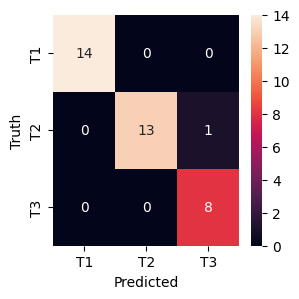

In [ ]:
plt.figure(figsize=(3,3))
sns.heatmap(cm,annot=True,xticklabels=['T1','T2','T3'],yticklabels=['T1','T2','T3'])
plt.xlabel('Predicted')
plt.ylabel('Truth')


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      0.93      0.96        14
           3       0.89      1.00      0.94         8

    accuracy                           0.97        36
   macro avg       0.96      0.98      0.97        36
weighted avg       0.98      0.97      0.97        36



In [ ]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(result)

     Actual  Predicted
19        1          1
45        1          1
140       3          3
30        1          1
67        2          2
16        1          1
119       2          2
174       3          3
109       2          2
141       3          3
24        1          1
150       3          3
41        1          1
118       2          3
15        1          1
111       2          2
113       2          2
82        2          2
9         1          1
114       2          2
18        1          1
66        2          2
60        2          2
169       3          3
171       3          3
164       3          3
117       2          2
65        2          2
90        2          2
55        1          1
29        1          1
128       2          2
145       3          3
31        1          1
12        1          1
42        1          1


# Importing Pickle file

In [ ]:
import pickle
with open('wine.pkl','wb') as file:
  pickle.dump(model,file)

In [ ]:
with open('scaler.pkl','wb') as file:
  pickle.dump(sc,file)

with open('wine.pkl','wb') as file:
  pickle.dump(model,file)